In [31]:
import os
print(os.getcwd())
print(os.listdir())


/content
['.config', 'sample_data']


hello


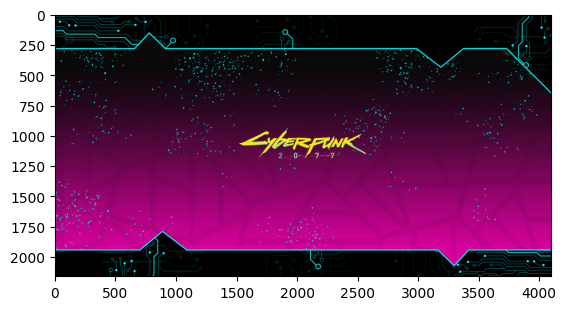

In [32]:
from PIL import Image
img = Image.open("/cyberpunk.png")


import matplotlib.pyplot as plt
plt.imshow(img)
print("hello")

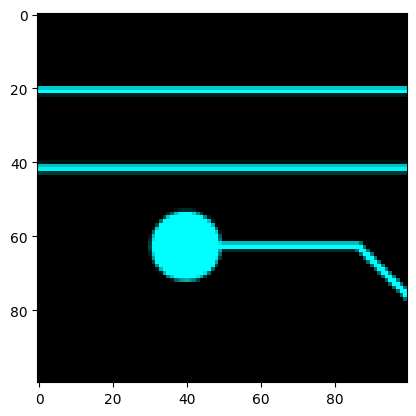

In [33]:
import numpy as np
img_array = np.array(img)
top_left = img_array[:100, :100]
plt.imshow(top_left)
plt.show()

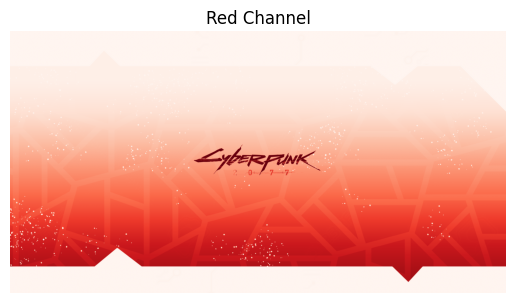

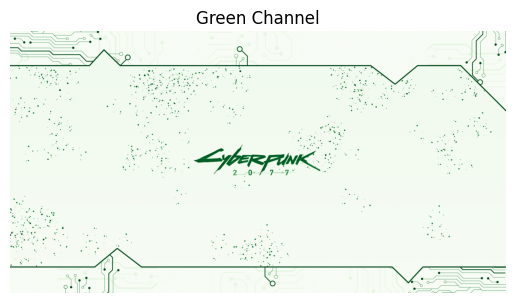

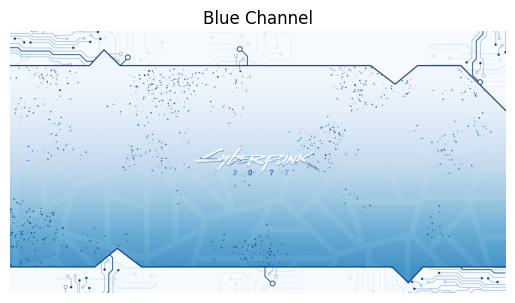

In [34]:
R = img_array[:,:,0]
G = img_array[:,:,1]
B = img_array[:,:,2]

plt.imshow(R, cmap='Reds'); plt.title("Red Channel"); plt.axis('off'); plt.show()
plt.imshow(G, cmap='Greens'); plt.title("Green Channel"); plt.axis('off'); plt.show()
plt.imshow(B, cmap='Blues'); plt.title("Blue Channel"); plt.axis('off'); plt.show()

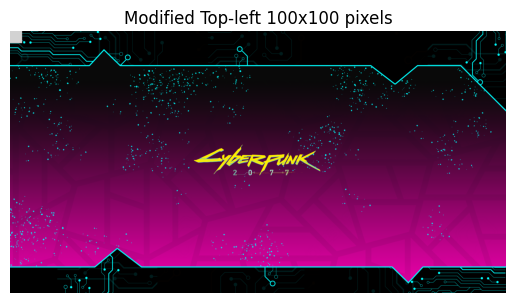

In [35]:
# Step 4: Modify top-left 100x100 pixels to value 210
img_array[:100, :100] = 210  # Light gray
plt.imshow(img_array)
plt.title("Modified Top-left 100x100 pixels")
plt.axis('off')
plt.show()

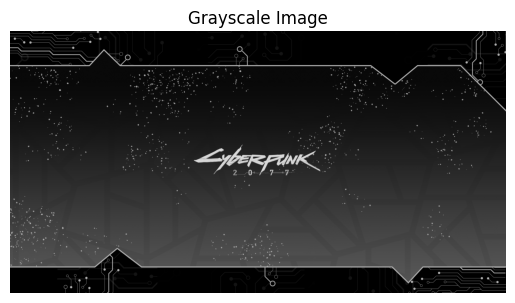

In [36]:
img_gray = Image.open("/cyberpunk.png").convert("L")
img_array = np.array(img_gray)

plt.imshow(img_gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

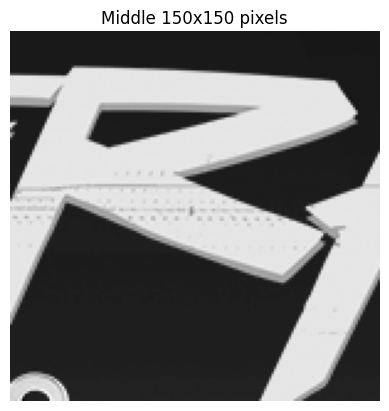

In [37]:
# Step 1: Extract middle 150x150 pixels
h, w = img_array.shape
center_crop = img_array[h//2-75:h//2+75, w//2-75:w//2+75]

plt.imshow(center_crop, cmap='gray')
plt.title("Middle 150x150 pixels")
plt.axis('off')
plt.show()

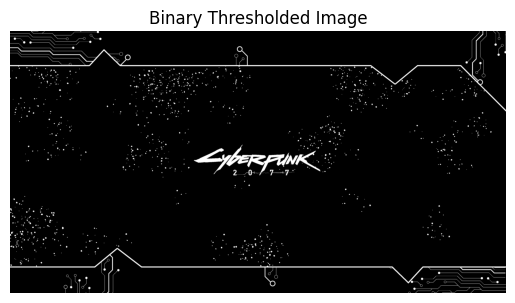

In [38]:
# Step 2: Apply threshold (binary image)
binary = np.where(img_array < 100, 0, 255)

plt.imshow(binary, cmap='gray')
plt.title("Binary Thresholded Image")
plt.axis('off')
plt.show()

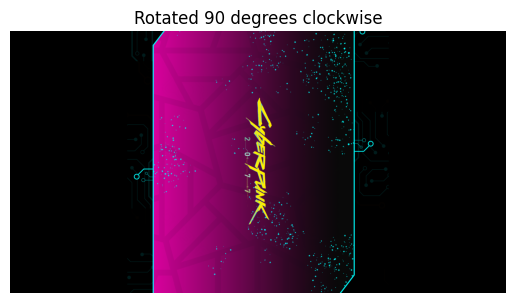

In [39]:
img = Image.open("/cyberpunk.png")

rotated = img.rotate(-90)


plt.imshow(rotated)
plt.title("Rotated 90 degrees clockwise")
plt.axis('off')
plt.show()

Grayscale shape: (2592, 4608)
111
[np.uint8(111), np.uint8(111), np.uint8(111)]
RGB shape: (2592, 4608, 3)


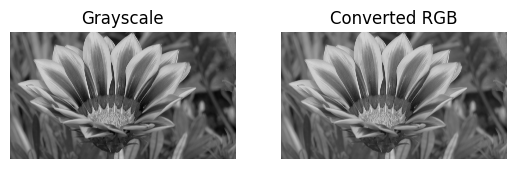

In [40]:

img = Image.open("/image1.jpg").convert("L")
img_array = np.array(img)
print("Grayscale shape:", img_array.shape)

print (img_array[50, 50])
rgb_array = np.stack([img_array, img_array, img_array], axis=-1)
pixel_values = [rgb_array[50, 50, i] for i in range(3)]

print(pixel_values)
print("RGB shape:", rgb_array.shape)

fig, axes = plt.subplots(1, 2)

axes[0].imshow(img_array, cmap='gray')
axes[0].set_title("Grayscale")
axes[0].axis('off')

axes[1].imshow(rgb_array)
axes[1].set_title("Converted RGB")
axes[1].axis('off')

plt.show()

In [41]:
img = Image.open("/image1.jpg").convert("L")
img_array = np.array(img, dtype=np.float64)

print("Image shape:", img_array.shape)

mean = np.mean(img_array, axis=0)
centered = img_array - mean

print("Mean shape:", mean.shape)
print("Centered shape:", centered.shape)

cov_matrix = np.cov(centered, rowvar=False)

print("Covariance matrix shape:", cov_matrix.shape)  # (W, W)

Image shape: (2592, 4608)
Mean shape: (4608,)
Centered shape: (2592, 4608)
Covariance matrix shape: (4608, 4608)


Eigenvalues shape: (4608,)
Eigenvectors shape: (4608, 4608)
Largest eigenvalue: 2320598.535072305
Smallest eigenvalue: -4.249374352838253e-10


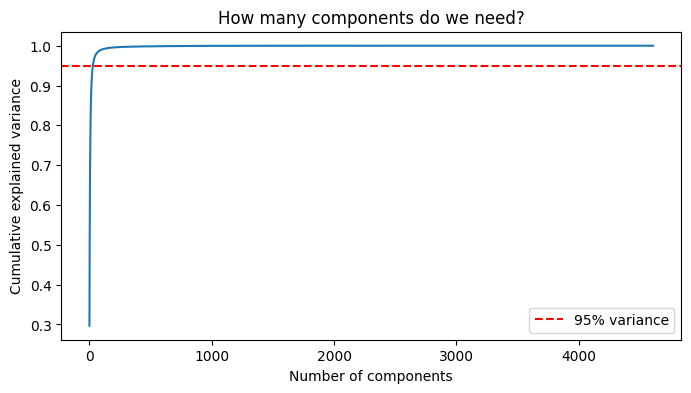

Components needed for 95% variance: 29


In [42]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)

sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

print("Largest eigenvalue:", eigenvalues[0])
print("Smallest eigenvalue:", eigenvalues[-1])
total_variance = np.sum(eigenvalues)
explained_variance = eigenvalues / total_variance
cumulative_variance = np.cumsum(explained_variance)


plt.figure(figsize=(8, 4))
plt.plot(cumulative_variance)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("How many components do we need?")
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.legend()
plt.show()

k = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed for 95% variance: {k}")

In [43]:
def reconstruct_image(centered, eigenvectors, k, mean):

    top_k = eigenvectors[:, :k]
    compressed = np.dot(centered, top_k)
    reconstructed = np.dot(compressed, top_k.T)
    reconstructed = reconstructed + mean
    reconstructed = np.clip(reconstructed, 0, 255).astype(np.uint8)
    return reconstructed

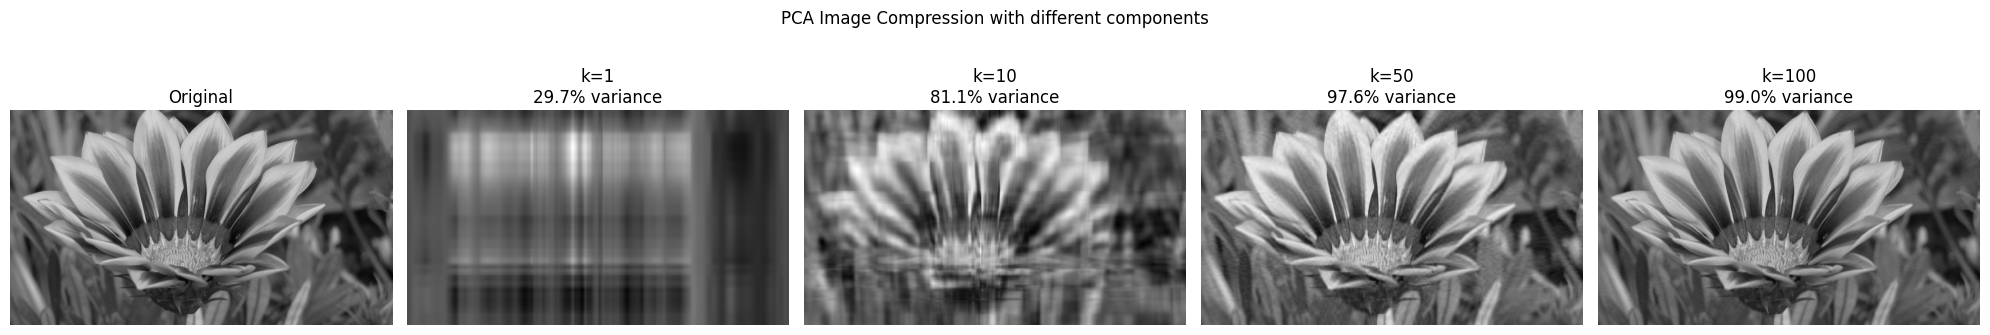

In [44]:
k_values = [1, 10, 50, 100]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))


axes[0].imshow(img_array, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')


for i, k in enumerate(k_values):
    reconstructed = reconstruct_image(centered, eigenvectors, k, mean)


    var = cumulative_variance[k-1] * 100

    axes[i+1].imshow(reconstructed, cmap='gray')
    axes[i+1].set_title(f"k={k}\n{var:.1f}% variance")
    axes[i+1].axis('off')

plt.suptitle("PCA Image Compression with different components")
plt.tight_layout()
plt.show()